https://bit.ly/FEML-13-cluster

# Кластеризация & метрики качества

In [184]:
import numpy as np

In [185]:
from matplotlib import pyplot as plt
import seaborn as sns

from matplotlib import rcParams
rcParams['figure.figsize'] = (8, 6)

In [186]:
import warnings
warnings.filterwarnings('ignore')

### Данные

в sklearn.datasets есть разные наборы данных, можно выбрать другие

In [187]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

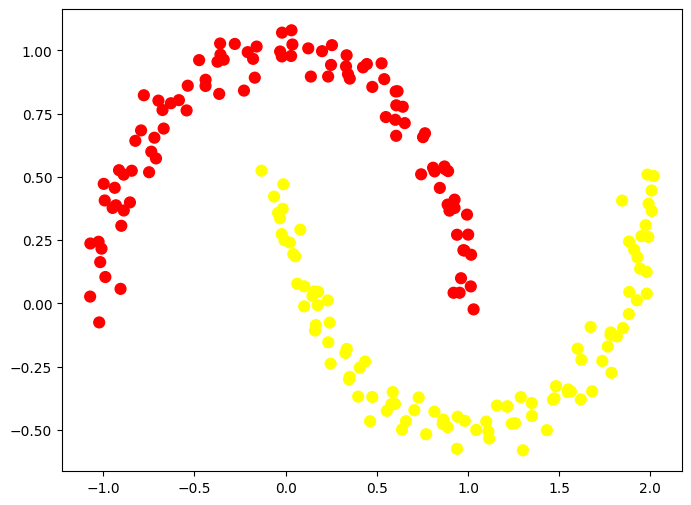

In [188]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn', s=60);

приведём данные по обеим осям к нормальному распределению

In [189]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.mean(axis=0), X_scaled.std(axis=0)
X_scaled

array([[ 0.36748451,  0.54576641],
       [ 1.28731953, -1.2803031 ],
       [-0.59397643,  0.04357482],
       [-1.74182239, -0.66371706],
       [ 1.45705144, -0.85667812],
       [ 1.58953574, -0.59675854],
       [ 0.54875768, -0.08552893],
       [ 0.44914675, -1.50218876],
       [ 0.46138047,  0.23124986],
       [ 0.71117525, -1.59382202],
       [-0.98693652,  1.16613579],
       [-0.28618307, -0.9941549 ],
       [ 1.51445888, -0.7760272 ],
       [ 0.82589866, -1.33505302],
       [-1.51451022,  0.79027655],
       [ 0.55545785, -0.08853775],
       [ 0.05104108,  1.284163  ],
       [-0.17030547, -1.12065006],
       [-0.1659644 ,  1.28843594],
       [-1.46106881,  1.15527198],
       [ 1.63987535, -0.48630812],
       [ 0.41814803, -1.47618916],
       [-0.34023715,  1.50810931],
       [ 0.90980627, -1.26183242],
       [-0.88905065,  1.56616629],
       [-0.29208555, -0.66541512],
       [ 1.55266276, -0.70888274],
       [ 1.59187607, -0.4198694 ],
       [-0.37934026,

форма осталась, но диапазоны выровнялись:

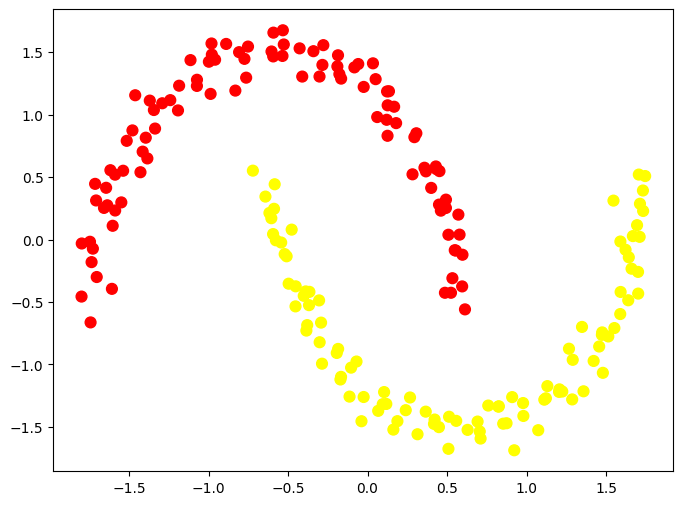

In [190]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn', s=60);

### Кластеризация

теперь кластеризуем с помощью различных методов

In [191]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [192]:
algorithms = [
    KMeans(n_clusters=2),
    AgglomerativeClustering(n_clusters=2),
    DBSCAN()
]

сделаем случайное предсказание

In [193]:
clusters_random = np.random.randint(low=0, high=2, size=len(X))

и функцию-заготовку, которая считает 2 метрики качества и генерирует заголовки для графиков

In [194]:
def get_descr(algo_name, y, y_pred, X):
    ari = adjusted_rand_score(y, y_pred)
    sil = silhouette_score(X, y_pred)
    return f"{algo_name}\nARI {ari:.2f}\nSilhouette {sil:.2f}"

проследите за ростом ARI и за падением Silhouette (хотя этот показатель по своему назначению тоже должен расти):

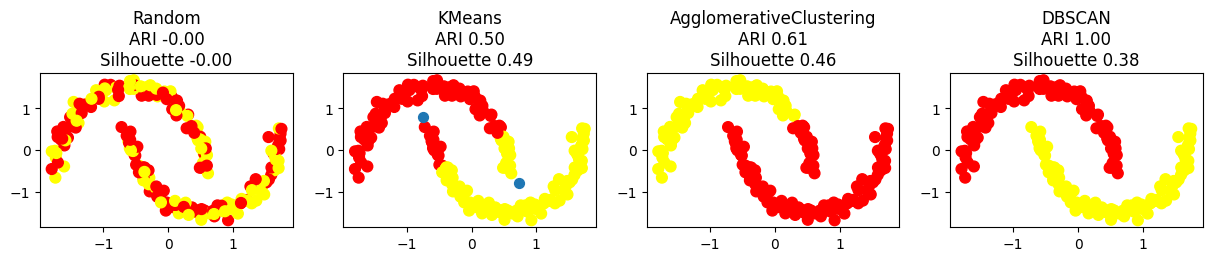

In [195]:
fig, axes = plt.subplots(1, 4, figsize=(15, 2))
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_random, cmap='autumn', s=60)
axes[0].set_title(get_descr("Random", y, clusters_random, X_scaled))

for ax, algorithm in zip(axes[1:], algorithms):
    # кластеризуем и выводим картинку
    clusters = algorithm.fit_predict(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='autumn', s=60)
    ax.set_title(get_descr(algorithm.__class__.__name__, y, clusters, X_scaled))

    # если есть центры кластеров - выведем их
    if algorithm.__class__.__name__ in {'KMeans'}:
        centers = algorithm.cluster_centers_
        ax.scatter(centers[:, 0], centers[:, 1], s=50)

## Подбор количества кластеров для KMeans

KMeans минимизирует сумму квадратов расстояний объектов классов до их центроидов. В обученном классификаторе это значение находится в поле inertia_

Посчитаем значения inertia при разном количестве кластеров. Они объективно стремятся к нулю с ростом числа кластеров (предельный случай: каждый объект - кластер, расстояние = 0)

In [196]:
k_inertia = []
ks = range(1,11)

for k in ks:
    clf_kmeans = KMeans(n_clusters=k)
    clusters_kmeans = clf_kmeans.fit_predict(X_scaled)
    k_inertia.append(clf_kmeans.inertia_)

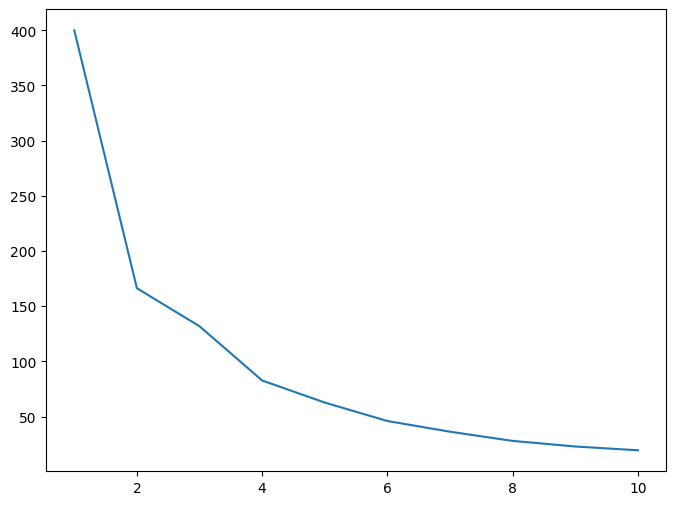

In [197]:
plt.plot(ks, k_inertia);

Как подобрать оптимальное значение? Будем на каждом шаге смотреть изменение inertia, и в тот момент, когда оно резко замедлится (относительно предыдущего изменения) мы и остановимся

Для начала считаем сами изменения

$${inertia_{k+1}-inertia_{k}}$$

In [198]:
diff = np.diff(k_inertia)

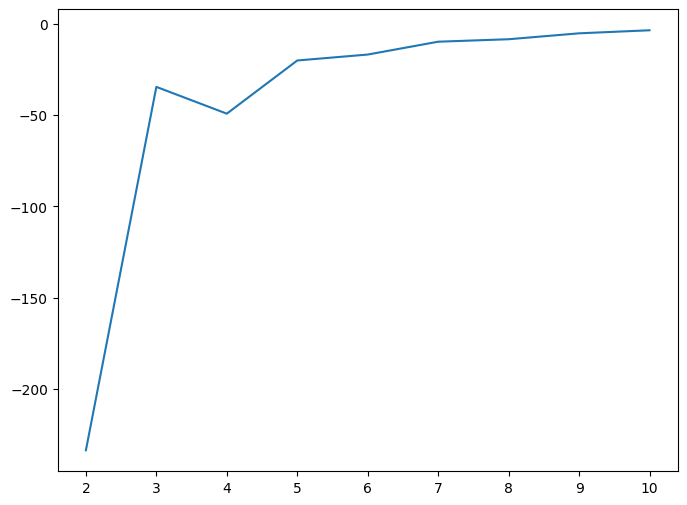

In [199]:
plt.plot(ks[1:], diff);

Теперь можно найти оптимальное число кластеров по этой формуле:

$$k_{opt} = argmin(\frac{inertia_{k+1}-inertia_{k}}{inertia_{k}-inertia_{k-1}})$$

In [200]:
diff[1:]

array([-34.46009171, -49.14981864, -19.98570965, -16.72780393,
        -9.68330607,  -8.33157158,  -5.08325328,  -3.4169576 ])

In [201]:
diff[:-1]

array([-233.76694672,  -34.46009171,  -49.14981864,  -19.98570965,
        -16.72780393,   -9.68330607,   -8.33157158,   -5.08325328])

In [202]:
diff_r = diff[1:] / diff[:-1]

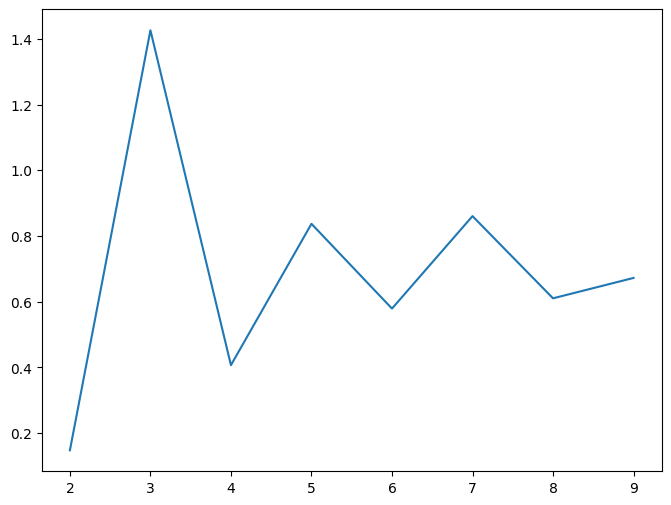

In [203]:
plt.plot(ks[1:-1], diff_r);

In [204]:
k_opt = ks[np.argmin(diff_r)+1]
k_opt

2

## Дендограмма

https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html

In [205]:
import numpy as np

from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

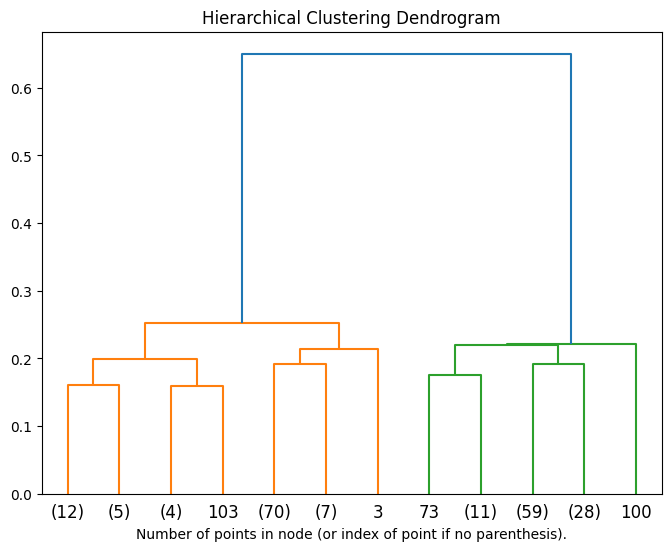

In [206]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='single')

model = model.fit(X_scaled)
plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(model, truncate_mode='level', p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

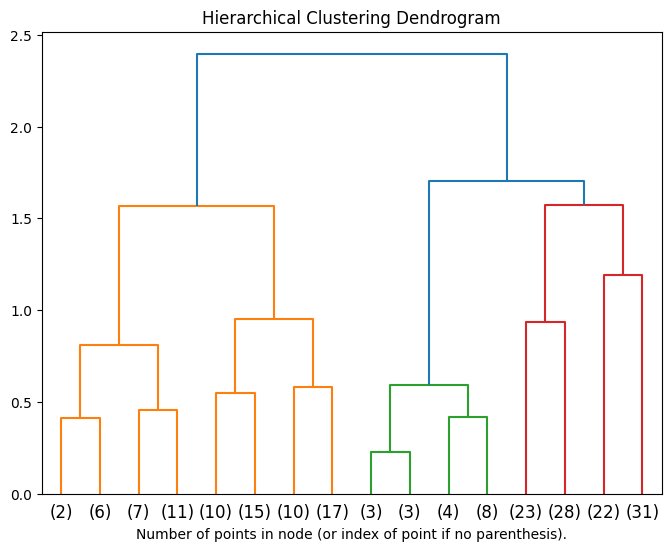

In [207]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='average')

model = model.fit(X_scaled)
plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(model, truncate_mode='level', p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

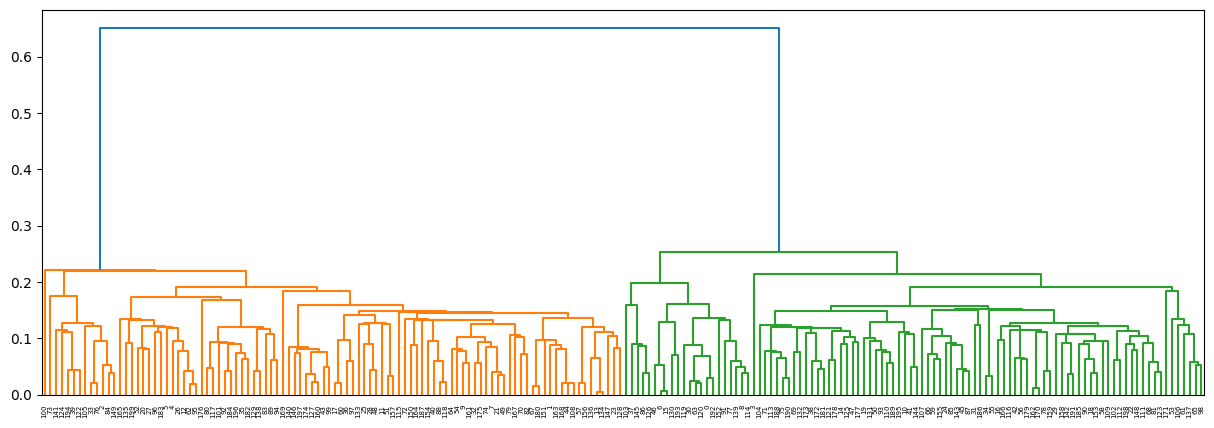

In [208]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

distance_mat = pdist(X_scaled)

Z = hierarchy.linkage(distance_mat, 'single')
plt.figure(figsize=(15,5))
dn = hierarchy.dendrogram(Z, color_threshold=0.5)

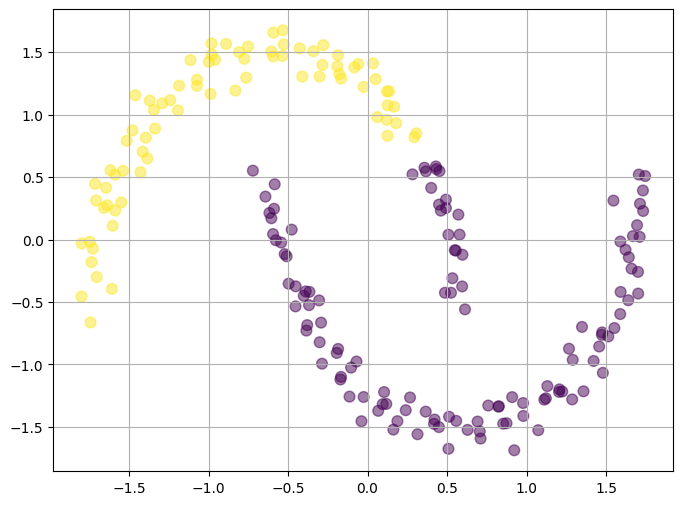

In [209]:
model = AgglomerativeClustering(n_clusters=2, linkage='ward')

preds = model.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=60, c=preds, alpha=0.5)
plt.grid()

In [210]:
centoid_1 = np.mean(X_scaled[preds == 1], axis=0)
centoid_0 = np.mean(X_scaled[preds == 0], axis=0)

centroids = np.vstack([centoid_0, centoid_1])
centroids

array([[ 0.55974769, -0.61028273],
       [-0.8755028 ,  0.95454478]])

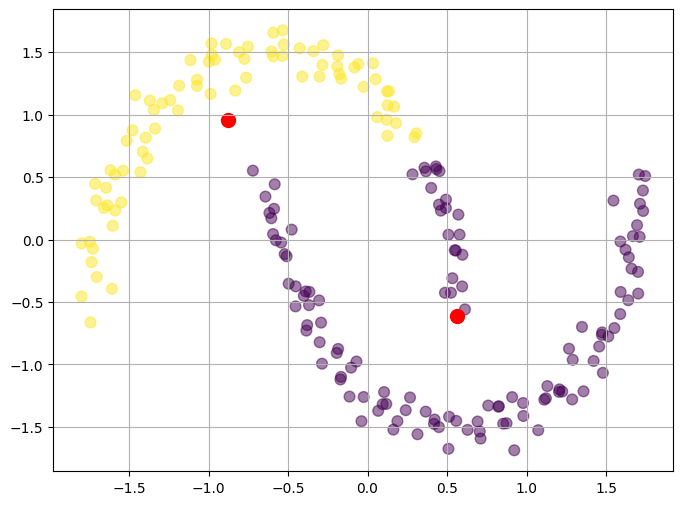

In [211]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=60, c=preds, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100)
plt.grid()

## DBSCAN

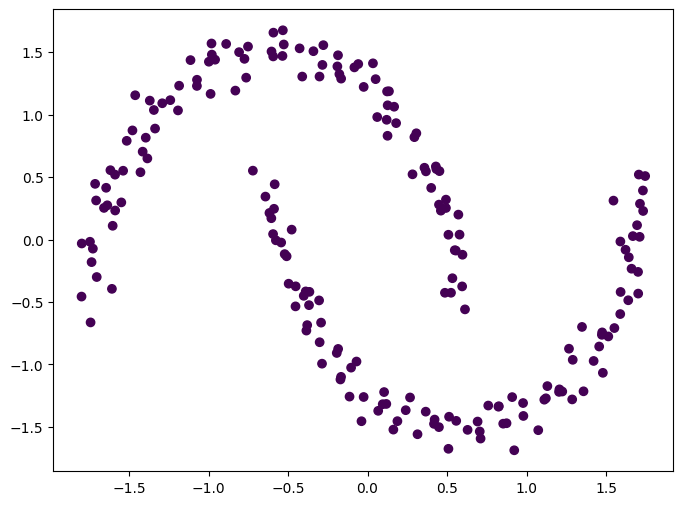

In [212]:
scan_moons = DBSCAN(eps=1)
preds = scan_moons.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=preds)
plt.show()

In [213]:
preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

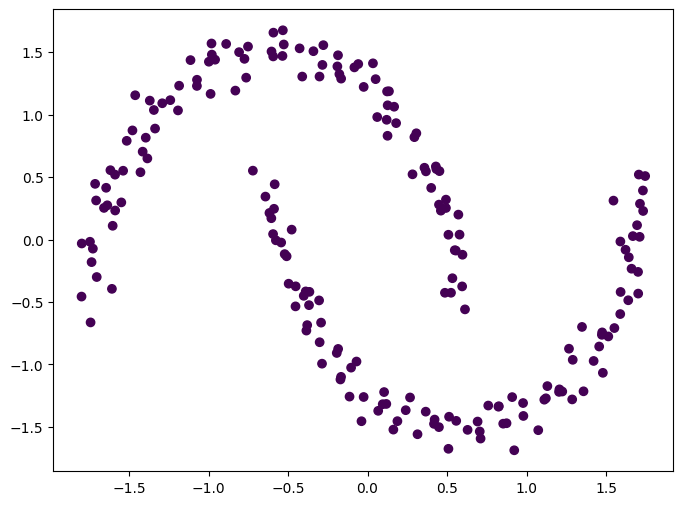

In [214]:
scan_moons = DBSCAN(eps=0.01)# указываем eps
preds = scan_moons.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=preds)
plt.show()

In [215]:
preds

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

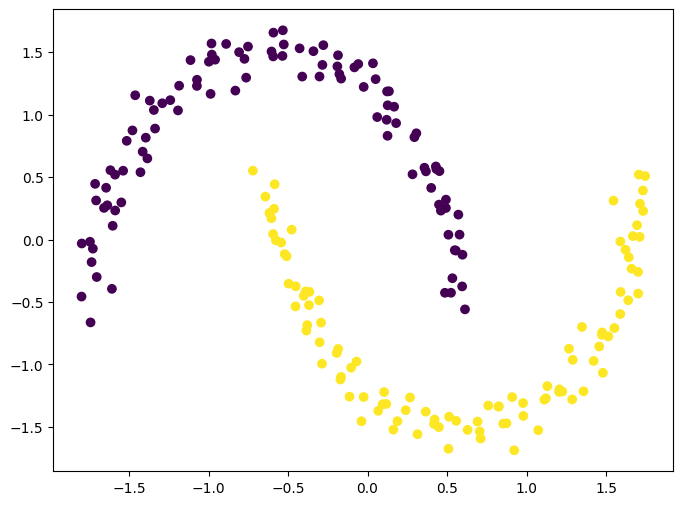

In [216]:
scan_moons = DBSCAN(eps=0.5) # путем подбора правильного eps приходим к верному кол-ву кластеров
preds = scan_moons.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=preds)
plt.show()

In [217]:
centoid_1 = np.mean(X_scaled[preds == 1], axis=0)
centoid_0 = np.mean(X_scaled[preds == 0], axis=0)

centroids = np.vstack([centoid_0, centoid_1])
centroids

array([[-0.57552068,  0.77174027],
       [ 0.57552068, -0.77174027]])

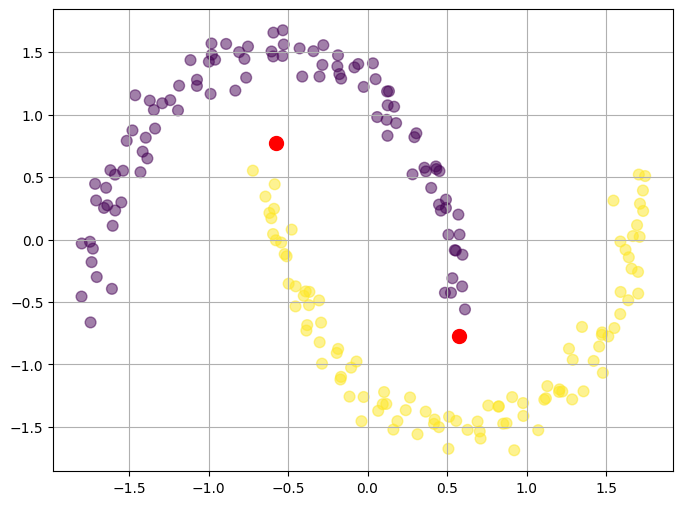

In [218]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=60, c=preds, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100)
plt.grid()

# Пример

Визуализация набора данных MNIST из [статьи](https://habr.com/ru/company/ods/blog/325654/)

In [219]:
import pandas as pd
import numpy as np

In [220]:
def display_components_in_2D_space(components_df, labels=None):
    components_with_labels_df = pd.concat([components_df, pd.DataFrame(labels)], axis=1)

    figsize = (10, 7)
    if labels is not None:
        components_with_labels_df.plot(kind='scatter', x='component_1', y='component_2',
                                         c=components_with_labels_df.iloc[:, -1], cmap=plt.get_cmap('jet'),
                                         alpha=0.5, figsize=figsize)
    else:
        components_with_labels_df.plot(kind='scatter', x='component_1', y='component_2', alpha=0.5, figsize=figsize)

    plt.xlabel('component_1')
    plt.ylabel('component_2')
    plt.title('2D mapping of objects')
    plt.show()

In [221]:
from sklearn import datasets


digits = datasets.load_digits()
X = digits.data
y = digits.target

In [222]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [223]:
y[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [224]:
X

array([[0.    , 0.    , 0.3125, ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.625 , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 1.    , 0.5625, 0.    ],
       ...,
       [0.    , 0.    , 0.0625, ..., 0.375 , 0.    , 0.    ],
       [0.    , 0.    , 0.125 , ..., 0.75  , 0.    , 0.    ],
       [0.    , 0.    , 0.625 , ..., 0.75  , 0.0625, 0.    ]],
      shape=(1797, 64))

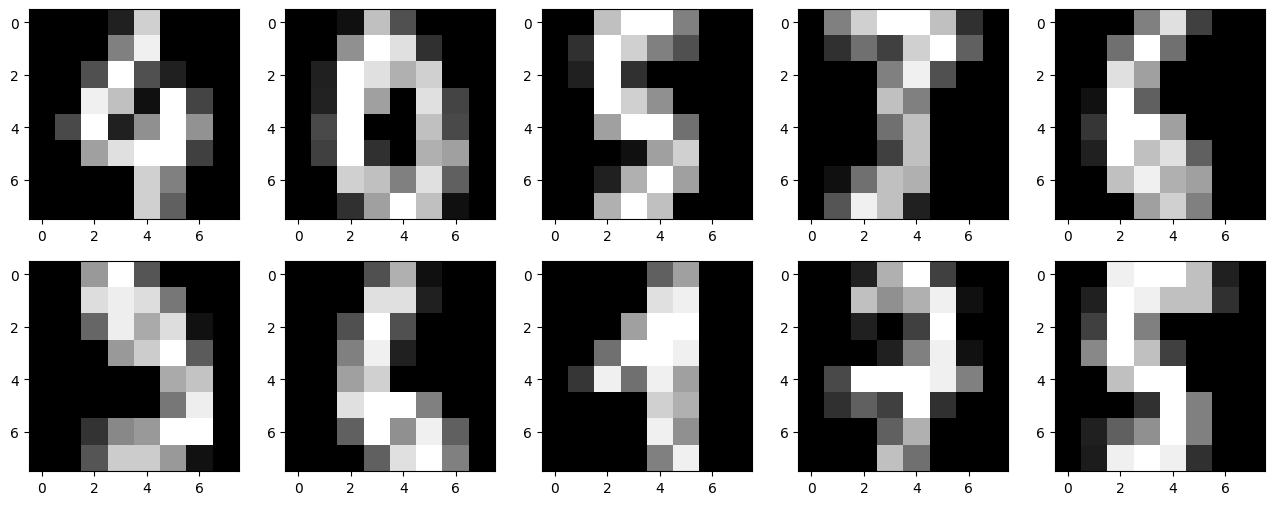

In [225]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i + 100,:].reshape([8,8]), cmap='gray')

**PCA**

In [226]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
X_reduced

array([[ 0.06113739, -1.37811679],
       [ 0.37573724,  1.35466438],
       [ 0.37052705,  0.67597542],
       ...,
       [ 0.61313384,  0.52192977],
       [-0.23032906, -0.82527455],
       [-0.02290219, -0.34818667]], shape=(1797, 2))

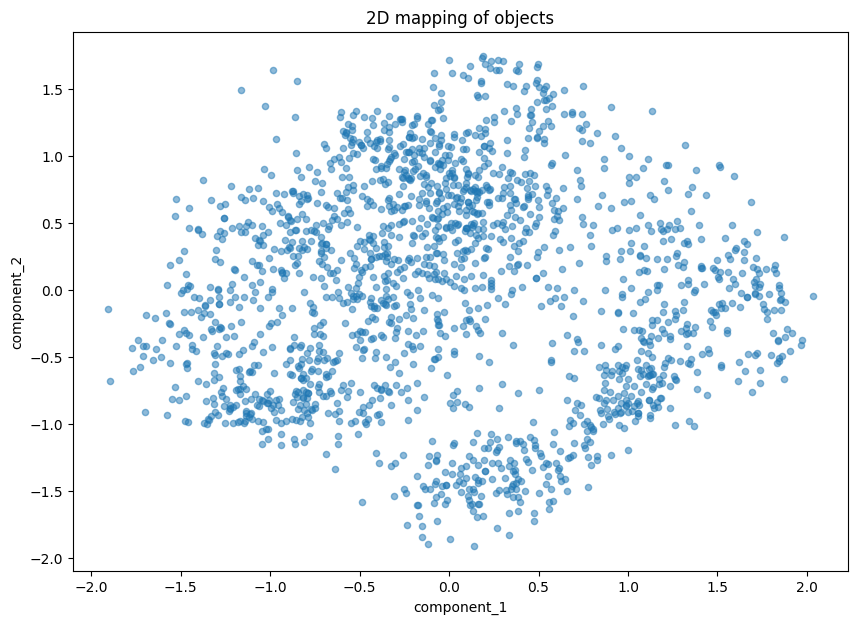

In [227]:
dims = 2
colnames = ['component_' + str(i) for i in range(1, dims+1)]
components_X_reduced = pd.DataFrame(data=X_reduced, columns=colnames)
components_X_reduced.head()

display_components_in_2D_space(components_X_reduced)

**TSNE**

In [228]:
%%time
from sklearn.manifold import TSNE

tsne = TSNE(random_state=17, perplexity=25)

X_tsne = tsne.fit_transform(X)

CPU times: total: 8.08 s
Wall time: 3.73 s


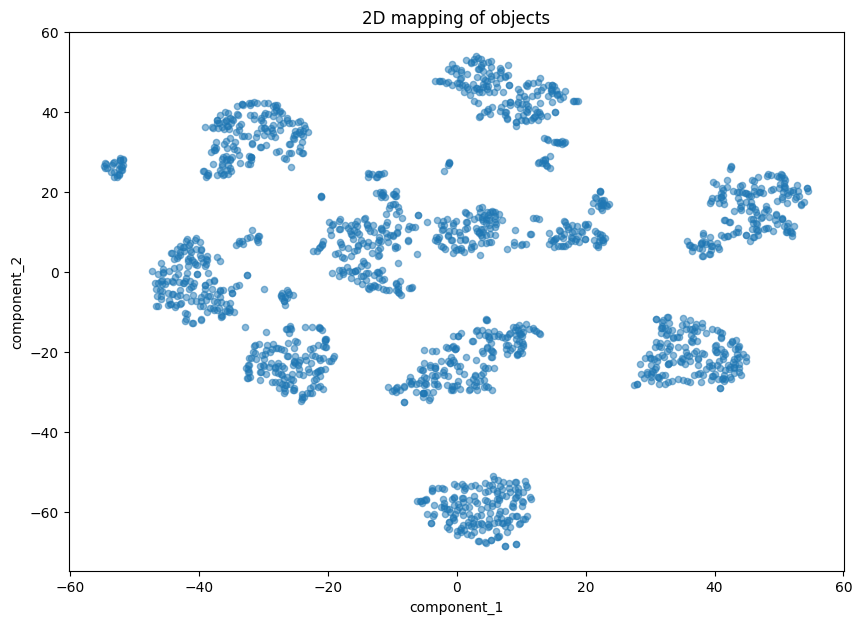

,component_1,component_2
0,-1.481810,-59.231461
1,11.350915,9.592692
2,-12.488118,23.730486
3,-37.687210,-7.277148
4,44.864784,9.216180
...,...,...
1792,-25.079056,-21.026047
1793,5.086087,-53.203487
1794,-7.478776,7.835520
1795,-22.258768,-18.998882


In [229]:
dims = 2
colnames = ['component_' + str(i) for i in range(1, dims+1)]
components_X_tsne = pd.DataFrame(data=X_tsne, columns=colnames)
components_X_tsne.head()

display_components_in_2D_space(components_X_tsne)
components_X_tsne

**KMeans**

In [230]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

In [231]:
kmeans = KMeans(n_clusters=10, random_state=42)
labels_clast = kmeans.fit_predict(X)
labels_clast = pd.Series(labels_clast, name='clusters')

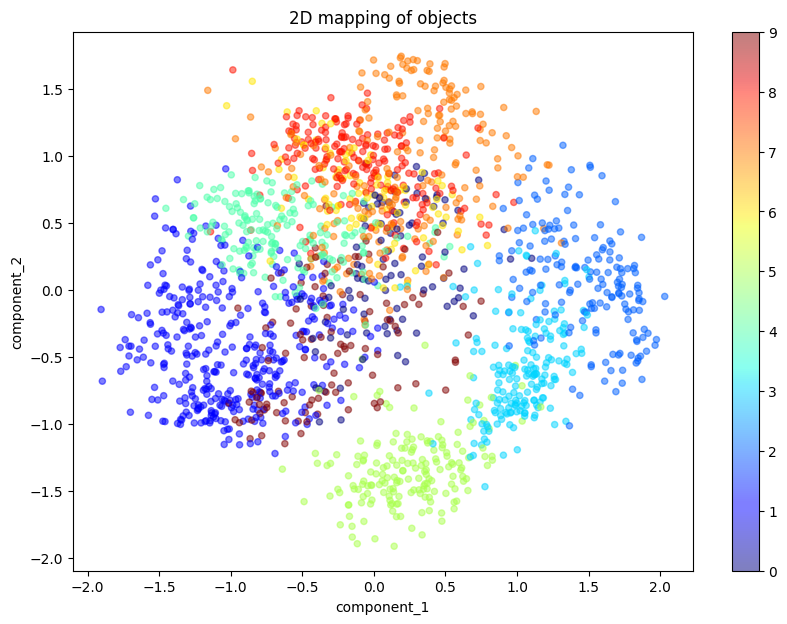

In [232]:
display_components_in_2D_space(components_X_reduced, labels=labels_clast)

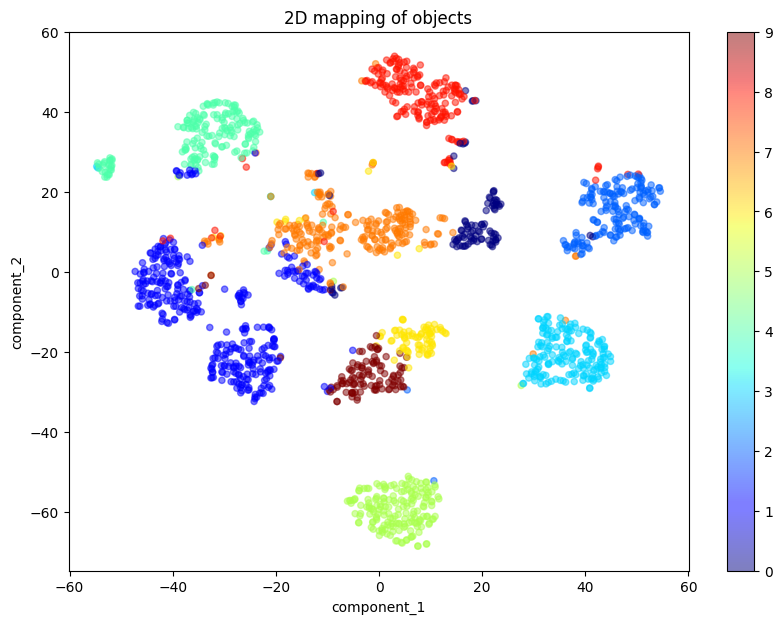

In [233]:
display_components_in_2D_space(components_X_tsne, labels=labels_clast)

**DBSCAN**

In [234]:
dbscan = DBSCAN(eps=1.5, min_samples=25)
labels_clast = dbscan.fit_predict(X)
labels_clast = pd.Series(labels_clast)

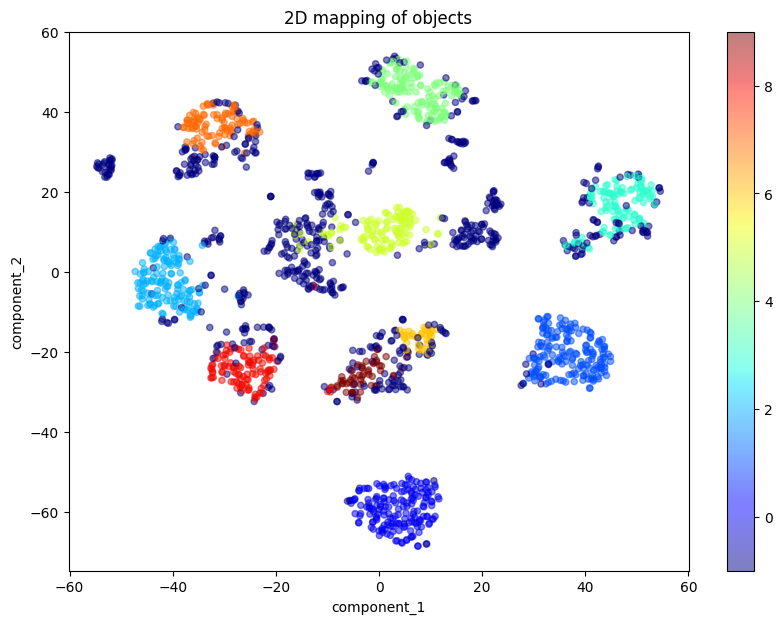

In [235]:
display_components_in_2D_space(components_X_tsne, labels=labels_clast)

**AgglomerativeClustering**

In [236]:
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

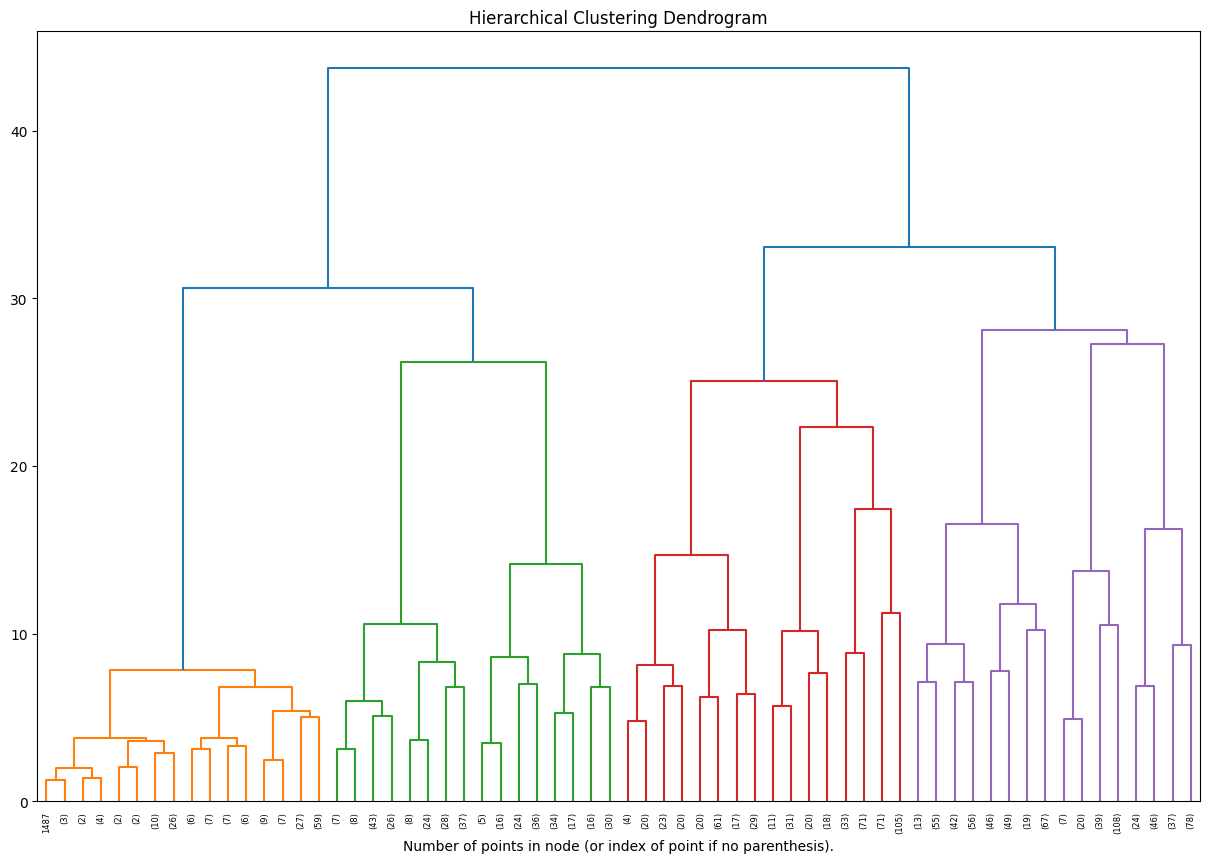

In [237]:
# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.figure(figsize=(15, 10))
plt.title('Hierarchical Clustering Dendrogram')
# plot the top three levels of the dendrogram

plot_dendrogram(model, truncate_mode='level', p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

In [238]:
%%time
aggl = AgglomerativeClustering(n_clusters=11)
labels_clast = aggl.fit_predict(X)
labels_clast = pd.Series(labels_clast)

CPU times: total: 62.5 ms
Wall time: 66.7 ms


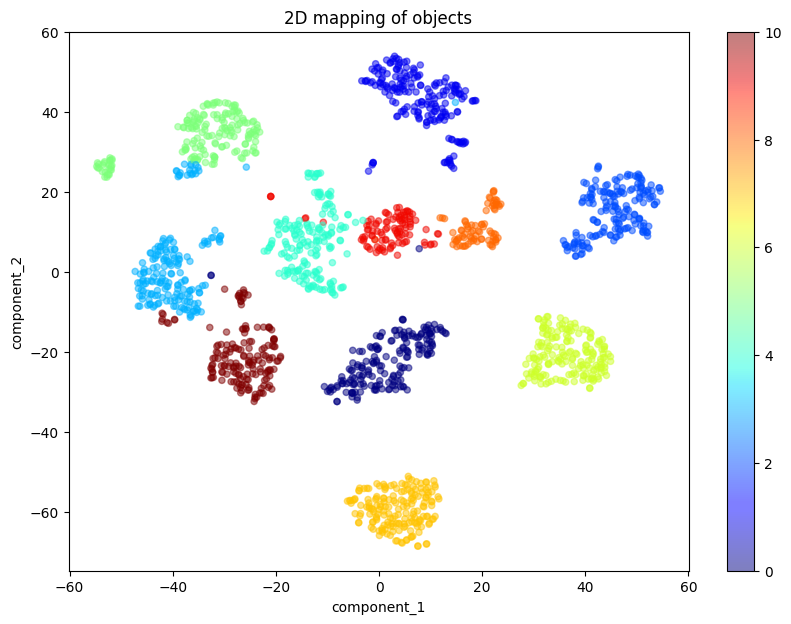

In [239]:
display_components_in_2D_space(components_X_tsne, labels=labels_clast)

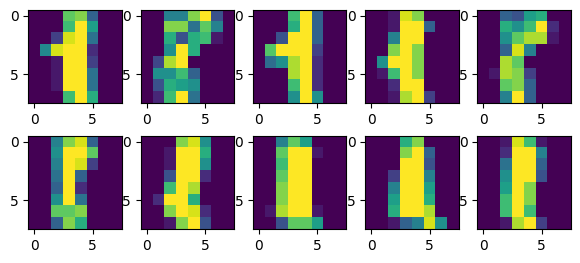

In [240]:
plt.figure(figsize=(7, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[labels_clast == 9][i,:].reshape([8,8]))

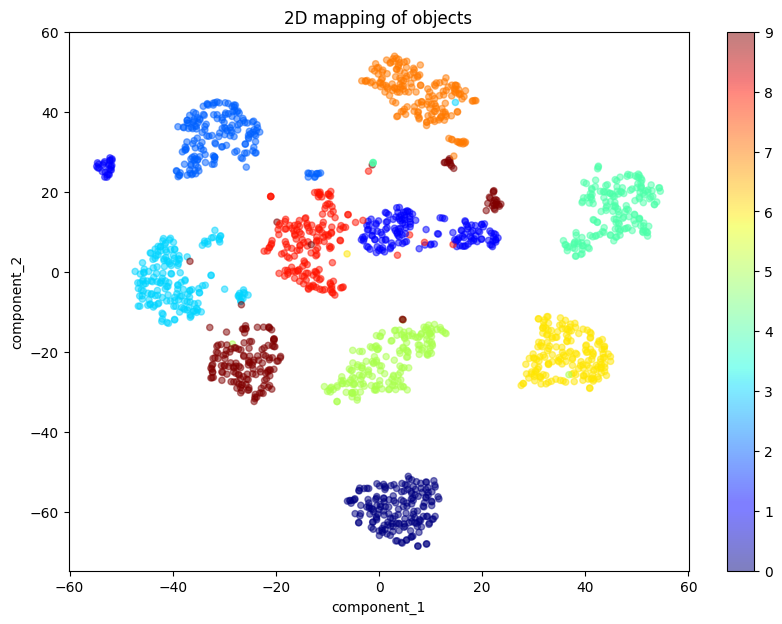

In [241]:
display_components_in_2D_space(components_X_tsne, labels=y)

## Дополнительные материалы
1.	Документация sklearn по кластеризации
http://scikit-learn.org/stable/modules/clustering.html
2. Метрики sklearn для задачкластеризации http://scikit-learn.org/stable/modules/classes.html
2. Open Data Science, habrahabr: Обучение без  учителя: PCA и кластеризация https://habrahabr.ru/company/ods/blog/325654/
3. Книжка https://cs7053.userapi.com/c812420/u4462765/docs/dbe264335e79/Introduction_to_ML_with_Python.pdf?extra=8V6L6yO8guwpde_XiD-plCoabKpDglwlaUl6TPHwVJ6bd-WBp5biUDb8PvXT8FsNoQcnMzcuYRd6qWKowntRuZ5fy3C4TkbgooCom26ARKvwTztOtZQvqQ&dl=1
4. Модель KMeans https://youtu.be/EHZJMz6zyFE
5. Метод локтя https://youtu.be/BEhLlqkL-f4
